In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import numpy as np
import random
import re
from pathlib import Path
from difflib import SequenceMatcher
import gzip

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations

import warnings
warnings.filterwarnings('ignore')

## Case-control selection

### Find diagnoses for full PMOA-TTS set and also for GLP subset

In [5]:
from pathlib import Path
import gzip
from typing import Dict, List, Optional, Set, Union

def load_dx2_diagnoses(
    base_dir: Union[str, Path],
    *,
    cases_dir: Optional[Union[str, Path]] = None,
    restrict_to_cases: bool = True,
    shard_range=range(12),
    dx_subdir: str = "anns/dx2",
    pattern: str = "PMC*_body.txt.bsv.gz",
    encoding: str = "utf-8",
) -> Dict[str, List[str]]:
    """
    Load diagnosis annotations from gzipped BSV files under a sharded PMC directory structure.

    Args:
      base_dir: root directory containing folders like PMC000xxxxxx/anns/dx2/
      cases_dir: directory containing case report files like PMC*_body.txt (used to restrict)
      restrict_to_cases: if True and cases_dir provided, only keep IDs in cases_dir
      shard_range: which shard folders to scan (default range(12) => PMC000xxxxxx..PMC011xxxxxx)
      dx_subdir: relative path within each shard folder to dx annotations
      pattern: filename glob under dx_subdir
      encoding: text encoding for gzip reading

    Returns:
      dict mapping base_id (e.g., 'PMC3075162_body') -> list of diagnoses (strings)
    """
    base_dir = Path(base_dir).expanduser().resolve()

    case_ids: Optional[Set[str]] = None
    if cases_dir is not None:
        cases_dir = Path(cases_dir).expanduser().resolve()
        # Build the subset list from case reports
        case_files = list(cases_dir.glob("PMC*_body.txt"))
        case_ids = {f.stem for f in case_files}

    diagnosis_data: Dict[str, List[str]] = {}

    for i in shard_range:
        folder = base_dir / f"PMC{i:03d}xxxxxx" / dx_subdir
        if not folder.exists():
            print(f"⚠️ Skipping missing folder: {folder}")
            continue

        for ann_file in folder.glob(pattern):
            base = ann_file.name.replace(".txt.bsv.gz", "")

            if restrict_to_cases and case_ids is not None and base not in case_ids:
                continue

            diagnoses: List[str] = []
            with gzip.open(ann_file, "rt", encoding=encoding) as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    # Your original used tab; keep same:
                    parts = line.split("\t")
                    if parts and parts[0]:
                        diagnoses.append(parts[0])

            if diagnoses:
                diagnosis_data[base] = diagnoses

    return diagnosis_data



In [314]:
diagnosis_data_glp

{'PMC3075162_body': ['Tropical calcific pancreatitis',
  'Acute suppuration of the pancreatic duct',
  'Non-insulin-dependent diabetes mellitus',
  'Exocrine pancreatic insufficiency',
  'Septicemia',
  'Acute respiratory distress syndrome',
  'Multiorgan failure'],
 'PMC3329809_body': ['HIV infection', 'Type 2 diabetes'],
 'PMC4578500_body': ['Prader–Willi syndrome',
  'Diabetes mellitus',
  'Ketoacidosis'],
 'PMC4433075_body': ['Type 2 diabetes',
  'Hypercholesterolemia',
  'Hypertension',
  'Deep venous thrombosis',
  'Vitamin D deficiency',
  'Obesity',
  'Depression',
  'Albuminuria'],
 'PMC4065292_body': ['Obesity',
  'Type 2 diabetes',
  'Osteoarthritis',
  'Disc herniation'],
 'PMC4802335_body': ['Morbid obesity',
  'Postprandial hyperinsulinemic hypoglycaemia (PHH)',
  'Bradycardia',
  'Asthma',
  'Gout'],
 'PMC4530374_body': ['Type 2 diabetes',
  'Morbid obesity',
  'Post-prandial hypoglycemia',
  'GLP1/glucagon co-secreting pancreatic neuroendocrine tumor'],
 'PMC4398013_bod

In [7]:
diagnosis_data = load_dx2_diagnoses(
    base_dir="/Users/kumars33/Desktop/CHARM_MIMIC/l33_pmc_anns/",
    cases_dir=None,
    restrict_to_cases=False,
)

diagnosis_data_glp = load_dx2_diagnoses(
    base_dir="/Users/kumars33/Desktop/CHARM_MIMIC/l33_pmc_anns/",
    cases_dir="/Users/kumars33/Desktop/Diabetes_LLM_annotation/final_manual_anns_n140/case_reports_n140/",
    restrict_to_cases=True,
)

# for key, value in list(diagnosis_data.items())[:5]:  # Show first 5 entries
#     print(f"File: {key}, Diagnosis: {value}")

# for key, value in list(diagnosis_data_glp.items())[:5]:  # Show first 5 entries
#     print(f"File: {key}, Diagnosis: {value}")

124699

### Find files with diabetes related keywords

In [9]:
import re

diabetes_keywords = [
    'diabetes', 'diabetic', 'dm', 'type 1', 'type 2', 'insulin', 'metabolic syndrome',
    'glucose', 'hyperglycem', 'hypoglycem', 'ketoacidosis', 'hba1c', 'glycosylated',
    'neuropathy', 'retinopathy', 'nephropathy', 'polyuria', 'polydipsia'
]

# Compile one regex for speed; use word boundaries for "dm" to avoid matching "admission" etc.
# Everything else is substring-like (diabetes, hyperglycem, etc.)
pattern = re.compile(
    r"(" +
    r"\bdm\b" + "|" +
    "|".join(re.escape(k) for k in diabetes_keywords if k != "dm") +
    r")",
    flags=re.IGNORECASE
)

def files_with_diabetes(dx_dict):
    """
    dx_dict examples:
      {"PMC3329809_body": ["HIV infection", "Type 2 diabetes"], ...}
    Returns:
      matched_files (sorted list), count
    """
    matched = []
    for fname, diagnoses in dx_dict.items():
        # be robust if diagnoses is None or a single string
        if diagnoses is None:
            continue
        if isinstance(diagnoses, str):
            diagnoses = [diagnoses]

        if any(pattern.search(str(d)) for d in diagnoses):
            matched.append(fname)

    matched.sort()
    return matched

# Example usage:
matched_diabetes_files_all= files_with_diabetes(diagnosis_data)
matched_diabetes_files_glp= files_with_diabetes(diagnosis_data_glp)

print("Number of total files from PMOA with diabetes keywords:{}".format(len(matched_diabetes_files_all)))
print("Number of total files from GLP-PMOA with diabetes keywords:{}".format(len(matched_diabetes_files_glp)))


#### Identify which exact keywords triggered the match
# import re

# def files_with_keyword_and_diagnoses(dx_dict, pattern: re.Pattern):
#     """
#     Returns:
#       {
#         filename: {
#           matched_keyword: [diagnosis1, diagnosis2, ...],
#           ...
#         },
#         ...
#       }
#     """
#     out = {}
#     for fname, diagnoses in dx_dict.items():
#         if diagnoses is None:
#             continue
#         if isinstance(diagnoses, str):
#             diagnoses = [diagnoses]

#         hit_map = {}  # keyword -> set(diagnoses)
#         for d in diagnoses:
#             d_str = str(d)
#             for m in pattern.finditer(d_str):
#                 kw = m.group(0).lower()
#                 hit_map.setdefault(kw, set()).add(d_str)

#         if hit_map:
#             # convert sets to sorted lists for stable output
#             out[fname] = {kw: sorted(list(ds)) for kw, ds in hit_map.items()}

#     return out

# triggers = files_with_keyword_and_diagnoses(diagnosis_data, pattern)


Number of total files from PMOA with diabetes keywords:14952
Number of total files from GLP-PMOA with diabetes keywords:120


#### Case: GLP case reports with diabetes. Diabetes patients who also took GLP
#### Control: Non-GLP case reports with diabetes. Diabetes patients who did not take GLP

In [11]:
diabetes_non_glp = list({x for x in matched_diabetes_files_all if x not in set(matched_diabetes_files_glp)})  # unique; drop set() if you want duplicates preserved

matched_diabetes_files_nonglp_eqsubset = random.Random(0).sample(diabetes_non_glp, k=len(matched_diabetes_files_glp))

diagnosis_control_diabetes_nonglp = {k: v for k, v in diagnosis_data.items() if k in matched_diabetes_files_nonglp_eqsubset}
diagnosis_case_diabetes_glp = {k: v for k, v in diagnosis_data_glp.items() if k in matched_diabetes_files_glp}


In [127]:
len(diagnosis_control_diabetes_nonglp.keys())

120

Hypertension                46
Obesity                     40
Type 2 diabetes mellitus    36
Type 2 diabetes             26
Dyslipidemia                16
Diabetes mellitus           12
Hyperlipidemia              11
Hypercholesterolemia         8
Hypothyroidism               8
Metabolic syndrome           7
Name: count, dtype: int64

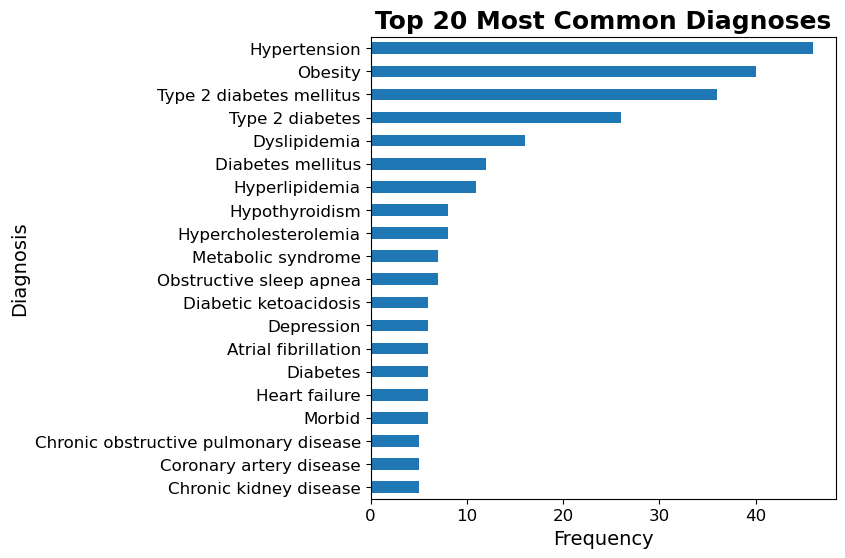

In [47]:
def plot_most_common_diag(diagnosis_data, title = ''):

    all_diagnoses_lst = [d for diagnoses in diagnosis_data.values() for d in diagnoses]
    
    # Count how many times each diagnosis appears
    diagnosis_counts = pd.Series(all_diagnoses_lst).value_counts()
    display(diagnosis_counts.head(10))
    
    #diagnosis_counts[:20].plot(kind='barh', figsize=(6, 6))
    diagnosis_counts[:20].sort_values(ascending=True).plot(kind = 'barh', figsize=(6, 6))
    plt.title("Top 20 Most Common Diagnoses", fontweight = 'bold', fontsize = 18)
    plt.xlabel("Frequency", fontsize = 14)
    plt.ylabel("Diagnosis", fontsize = 14)
    plt.xticks(fontsize = 12)
    plt.yticks(fontsize = 12)
    #plt.show()

    plt.savefig('/Users/kumars33/Desktop/Diabetes_LLM_annotation/GLP_AMIA/paper_plots/top20_diagnoses_glp.pdf', dpi=300, bbox_inches='tight')

with open("glp_linked_diagnosis_data.pkl", "rb") as f:
    diagnosis_data = pickle.load(f)
    
plot_most_common_diag(diagnosis_data, title = '')

# plot_most_common_diag(diagnosis_case_diabetes_glp, title = 'Case group: Diabetes GLP (n = 120')
# plot_most_common_diag(diagnosis_control_diabetes_nonglp, title = 'Control group: Diabetes non-GLP (n=120)')

In [15]:
import spacy
from scispacy.linking import EntityLinker

# Load the model and add the linker
nlp = spacy.load("en_core_sci_lg")
nlp.add_pipe("scispacy_linker", config={"resolve_abbreviations": True, "linker_name": "umls"})
linker = nlp.get_pipe("scispacy_linker")


# Function to map one diagnosis string to UMLS concepts
def link_diagnosis_text_as_dict(text, threshold=0.8, top_k=3):
    doc = nlp(text)
    linked_results = {}

    for ent in doc.ents:
        kb_ents = ent._.kb_ents
        if not kb_ents:
            continue

        # Filter by threshold, or fallback to top_k
        filtered = [(cui, score) for cui, score in kb_ents if score >= threshold]
        if not filtered:
            filtered = kb_ents[:top_k]

        linked_concepts = [
            {
                "cui": cui,
                "name": linker.kb.cui_to_entity[cui].canonical_name,
                "score": round(score, 4)
            }
            for cui, score in filtered
        ]

        linked_results[ent.text] = linked_concepts

    return linked_results

In [133]:
def create_linked_diag_data(diagnosis_data):

    from tqdm import tqdm
    linked_diagnosis_data = {}
    
    for pmc_id, diagnoses in tqdm(diagnosis_data.items(), desc="Linking diagnoses", unit="file"):
        diag_links = {}
        for diag in diagnoses:
            links = link_diagnosis_text_as_dict(diag)
            diag_links.update(links)
        linked_diagnosis_data[pmc_id] = diag_links

    return linked_diagnosis_data


linked_diag_case = create_linked_diag_data(diagnosis_case_diabetes_glp)
linked_diag_control = create_linked_diag_data(diagnosis_control_diabetes_nonglp)

with open("diagnosis_case_diabetes_glp.pkl", "wb") as f:
    pickle.dump(linked_diag_case, f)

with open("diagnosis_control_diabetes_nonglp.pkl", "wb") as f:
    pickle.dump(linked_diag_control, f)


Linking diagnoses: 100%|████████████████████| 120/120 [00:37<00:00,  3.21file/s]


In [181]:
baal = linked_diag_case[list(linked_diag_case.keys())[0]]

In [316]:
linked_diag_case

{'PMC3075162_body': {'Tropical calcific pancreatitis': [{'cui': 'C1842402',
    'name': 'TROPICAL CALCIFIC PANCREATITIS',
    'score': 0.9814}],
  'Acute suppuration': [{'cui': 'C3203360',
    'name': 'Suppuration',
    'score': 0.7753}],
  'pancreatic duct': [{'cui': 'C0030288',
    'name': 'Pancreatic duct',
    'score': 0.9861},
   {'cui': 'C4482304', 'name': 'Abdomen>Pancreatic duct', 'score': 0.9861},
   {'cui': 'C0447557', 'name': 'Main pancreatic duct', 'score': 0.8683},
   {'cui': 'C0341492', 'name': 'Pancreatic duct calculus', 'score': 0.8597},
   {'cui': 'C0030274', 'name': 'Pancreas', 'score': 0.8297}],
  'Non-insulin-dependent diabetes mellitus': [{'cui': 'C0011860',
    'name': 'Diabetes Mellitus, Non-Insulin-Dependent',
    'score': 0.9731},
   {'cui': 'C0011854',
    'name': 'Diabetes Mellitus, Insulin-Dependent',
    'score': 0.9016},
   {'cui': 'C1337112', 'name': 'INS gene', 'score': 0.8864}],
  'Exocrine pancreatic insufficiency': [{'cui': 'C0267963',
    'name': 'Ex

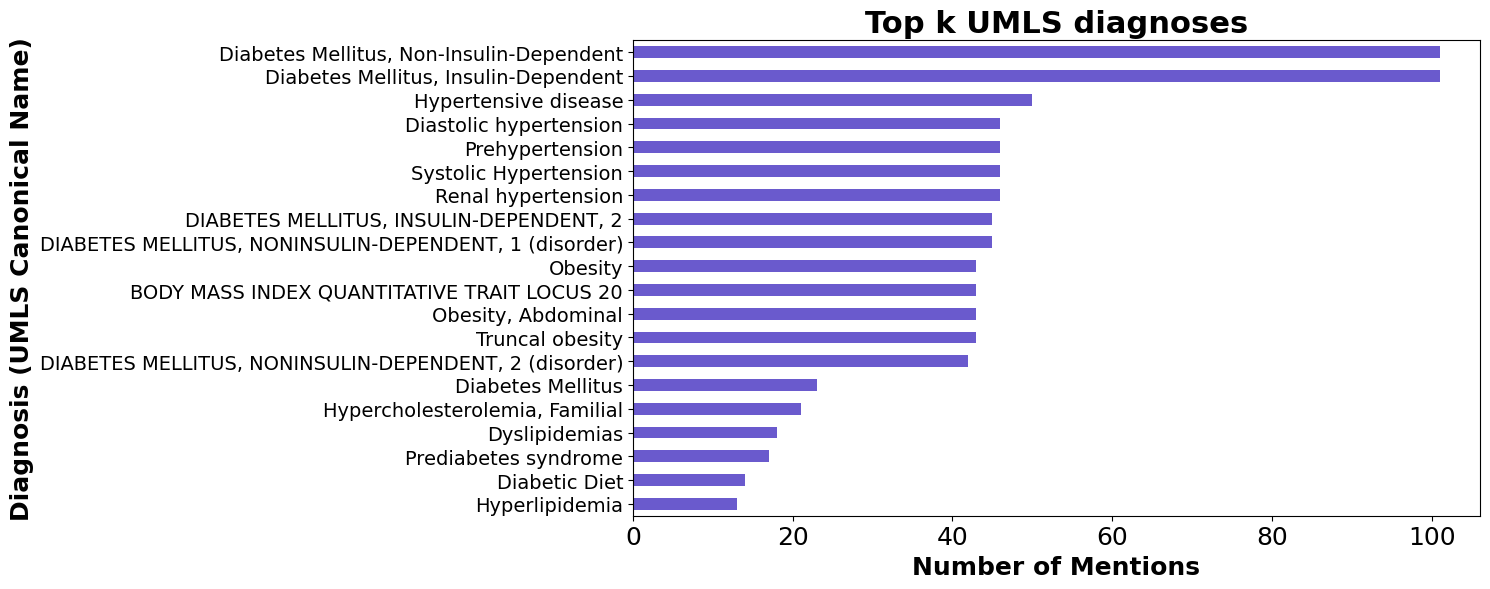

In [19]:
# -------------------------------
# Load your sampled pickle file
# -------------------------------
with open("glp_linked_diagnosis_data.pkl", "rb") as f:
    diagnosis_data = pickle.load(f)


def plot_topk_diagnoses(diagnosis_data, title = ''):

    # -------------------------------
    # Count UMLS canonical names and collect mapping scores
    # -------------------------------
    canonical_name_counter = Counter()
    cui_score_list = []
    
    for diag_dict in diagnosis_data.values():
        for cuis in diag_dict.values():
            for cui_info in cuis:
                canonical_name = cui_info["name"]
                canonical_name_counter[canonical_name] += 1
                cui_score_list.append(cui_info["score"])
    
    
    # -------------------------------
    # Remove noisy or survey-style entries
    # -------------------------------
    filtered_canonical_counter = canonical_name_counter.copy()
    to_remove = [name for name in canonical_name_counter if "ever told you" in name.lower() or ":" in name.lower()]
    for name in to_remove:
        del filtered_canonical_counter[name]


    # Prepare the data
    top_canonical_df = pd.DataFrame(
        filtered_canonical_counter.most_common(20),
        columns=["Diagnosis (UMLS Canonical Name)", "Count"]
    )
    
    # Sort the DataFrame by Count
    top_canonical_df = top_canonical_df.sort_values(by="Count")
    top_canonical_df['Count'] /= 1
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Create the horizontal bar plot
    top_canonical_df.plot(
        kind='barh',
        x='Diagnosis (UMLS Canonical Name)',
        y='Count',
        legend=False,
        color='slateblue',
        ax=ax,
        fontsize=18,
    )
    
    # Customize the plot
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_xlabel('Number of Mentions', fontsize=18, fontweight='bold')
    ax.set_ylabel('Diagnosis (UMLS Canonical Name)', fontsize=18, fontweight='bold')
    ax.tick_params(axis='y', labelsize=14)
    plt.tight_layout()


# data_case = pd.read_pickle('diagnosis_case_diabetes_glp.pkl')
# data_control = pd.read_pickle('diagnosis_control_diabetes_nonglp.pkl')

data_glp = pd.read_pickle('glp_linked_diagnosis_data.pkl')

plot_topk_diagnoses(data_glp, title = 'Top k UMLS diagnoses')

# plot_topk_diagnoses(data_case, title = 'Top k UMLS diagnoses (case)')

# plot_topk_diagnoses(data_control, title = 'Top k UMLS diagnoses (control)')

# -------------------------------
# Bar Plot: Top 20 UMLS Canonical Diagnoses
# -------------------------------
import matplotlib.pyplot as plt
import pandas as pd

# Prepare the data
top_canonical_df = pd.DataFrame(
    filtered_canonical_counter.most_common(20),
    columns=["Diagnosis (UMLS Canonical Name)", "Count"]
)

# Sort the DataFrame by Count
top_canonical_df = top_canonical_df.sort_values(by="Count")
top_canonical_df['Count'] /= 1

# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 6))

# Create the horizontal bar plot
top_canonical_df.plot(
    kind='barh',
    x='Diagnosis (UMLS Canonical Name)',
    y='Count',
    legend=False,
    color='slateblue',
    ax=ax,
    fontsize=18,
)

# Customize the plot
ax.set_title('Top 20 Diagnoses', fontsize=22, fontweight='bold')
ax.set_xlabel('Number of Mentions', fontsize=18, fontweight='bold')
ax.set_ylabel('Diagnosis (UMLS Canonical Name)', fontsize=18, fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
plt.tight_layout()

# Save the figure
#fig.savefig("top_diagnoses_umls.pdf", dpi=300)
# plt.close(fig)  # Optional: close to free memory

# -------------------------------
# Histogram with CDF overlay: UMLS Mapping Scores
# -------------------------------
# plt.figure(figsize=(8, 5))
# counts, bins, _ = plt.hist(cui_score_list, bins=30, edgecolor='black', color='darkorange', alpha=0.6, label='Histogram')
# cdf = np.cumsum(counts) / sum(counts)
# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# plt.plot(bin_centers, cdf * max(counts), color='blue', linewidth=2.5, label='CDF (rescaled)')
# plt.title('Distribution of UMLS Mapping Scores with CDF')
# plt.xlabel('Mapping Score')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.savefig("umls_mapping_score_distribution_with_cdf.png")
# # plt.close()

# -------------------------------
# Co-occurrence Heatmap (Top 30) — Log Scale
# -------------------------------
top_k = 30
top_canonical_df_k = pd.DataFrame(filtered_canonical_counter.most_common(top_k), columns=["Diagnosis (UMLS Canonical Name)", "Count"])
canonical_set_k = set(top_canonical_df_k["Diagnosis (UMLS Canonical Name)"])

cooccurrence_counter_k = defaultdict(int)
for diag_dict in diagnosis_data.values():
    canonical_names = []
    for cuis in diag_dict.values():
        canonical_names.extend([cui_info["name"] for cui_info in cuis])
    filtered = [n for n in canonical_names if n in canonical_set_k]
    for d1, d2 in combinations(sorted(set(filtered)), 2):
        cooccurrence_counter_k[(d1, d2)] += 1

canonical_diag_list_k = sorted(canonical_set_k)
cooccurrence_df_k = pd.DataFrame(0, index=canonical_diag_list_k, columns=canonical_diag_list_k)
for (d1, d2), count in cooccurrence_counter_k.items():
    cooccurrence_df_k.loc[d1, d2] = count
    cooccurrence_df_k.loc[d2, d1] = count

plt.figure(figsize=(15, 13))
sns.heatmap(
    np.log1p(cooccurrence_df_k),
    cmap='viridis',
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'log(1 + Co-occurrence Count)'}
)
plt.title("Diagnosis Co-occurrence Heatmap (Top 30, Log Scale, UMLS Canonical Names)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cooccurrence_heatmap_top30_logscale.png")
# plt.close()

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from itertools import combinations

# -------------------------------
# Load your sampled pickle file
# -------------------------------
with open("glp_linked_diagnosis_data.pkl", "rb") as f:
    diagnosis_data = pickle.load(f)

# -------------------------------
# Count UMLS canonical names and collect mapping scores
# -------------------------------
canonical_name_counter = Counter()
cui_score_list = []

for diag_dict in diagnosis_data.values():
    for cuis in diag_dict.values():
        for cui_info in cuis:
            canonical_name = cui_info["name"]
            canonical_name_counter[canonical_name] += 1
            cui_score_list.append(cui_info["score"])

# -------------------------------
# Remove noisy or survey-style entries
# -------------------------------
filtered_canonical_counter = canonical_name_counter.copy()
to_remove = [name for name in canonical_name_counter if "ever told you" in name.lower() or ":" in name.lower()]
for name in to_remove:
    del filtered_canonical_counter[name]

# -------------------------------
# Bar Plot: Top 20 UMLS Canonical Diagnoses
# -------------------------------
top_canonical_df = pd.DataFrame(filtered_canonical_counter.most_common(20), columns=["Diagnosis (UMLS Canonical Name)", "Count"])
plt.figure(figsize=(10, 6))
top_canonical_df.sort_values(by="Count").plot(
    kind='barh', x='Diagnosis (UMLS Canonical Name)', y='Count',
    legend=False, color='slateblue'
)
plt.title('Top 20 Diagnoses (UMLS Canonical Names)')
plt.xlabel('Number of Mentions')
plt.tight_layout()
plt.savefig("top_diagnoses_umls.png")
plt.close()

# -------------------------------
# Histogram with CDF overlay: UMLS Mapping Scores
# -------------------------------
plt.figure(figsize=(10, 6))
counts, bins, _ = plt.hist(cui_score_list, bins=30, edgecolor='black', color='darkorange', alpha=0.6, label='Histogram')
cdf = np.cumsum(counts) / sum(counts)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.plot(bin_centers, cdf * max(counts), color='blue', linewidth=2.5, label='CDF (rescaled)')
plt.title('Distribution of UMLS Mapping Scores with CDF')
plt.xlabel('Mapping Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("umls_mapping_score_distribution_with_cdf.png")
plt.close()

# -------------------------------
# Co-occurrence Heatmap (Top 30) — Log Scale
# -------------------------------
top_k = 30
top_canonical_df_k = pd.DataFrame(filtered_canonical_counter.most_common(top_k), columns=["Diagnosis (UMLS Canonical Name)", "Count"])
canonical_set_k = set(top_canonical_df_k["Diagnosis (UMLS Canonical Name)"])

cooccurrence_counter_k = defaultdict(int)
for diag_dict in diagnosis_data.values():
    canonical_names = []
    for cuis in diag_dict.values():
        canonical_names.extend([cui_info["name"] for cui_info in cuis])
    filtered = [n for n in canonical_names if n in canonical_set_k]
    for d1, d2 in combinations(sorted(set(filtered)), 2):
        cooccurrence_counter_k[(d1, d2)] += 1

canonical_diag_list_k = sorted(canonical_set_k)
cooccurrence_df_k = pd.DataFrame(0, index=canonical_diag_list_k, columns=canonical_diag_list_k)
for (d1, d2), count in cooccurrence_counter_k.items():
    cooccurrence_df_k.loc[d1, d2] = count
    cooccurrence_df_k.loc[d2, d1] = count

plt.figure(figsize=(15, 13))
sns.heatmap(
    np.log1p(cooccurrence_df_k),
    cmap='viridis',
    xticklabels=True,
    yticklabels=True,
    cbar_kws={'label': 'log(1 + Co-occurrence Count)'}
)
plt.title("Diagnosis Co-occurrence Heatmap (Top 30, Log Scale, UMLS Canonical Names)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cooccurrence_heatmap_top30_logscale.png")
plt.close()

# -------------------------------
# Clustered Heatmap (Top 30) — Log Scale
# -------------------------------
log_scaled_matrix = np.log1p(cooccurrence_df_k)
g = sns.clustermap(
    log_scaled_matrix,
    cmap='viridis',
    figsize=(16, 14),
    metric='euclidean',
    method='ward',
    linewidths=0.5,
    cbar_kws={'label': 'log(1 + Co-occurrence Count)'},
)
g.fig.suptitle("Clustered Diagnosis Co-occurrence Heatmap (Top 30, Log Scale)", y=1.02)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=15)  # Increase x-axis tick label font size
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=15)  # Increase y-axis tick label font size
g.savefig("clustered_cooccurrence_heatmap_top30.pdf")

## US prevalence of disease categories

| Disease Group | US Prevalence | Source & Link |
| :--- | :--- | :--- |
| **Cardiovascular** | **48.6%** | [AHA Heart Disease & Stroke Statistics 2023](https://www.ahajournals.org/doi/10.1161/CIR.0000000000001123)<br>*(Comprises all CVD: Hypertension, CHD, Heart Failure, Stroke)* |
| **Oral & Dental Health** | **42.0%** | [CDC Periodontal Disease Facts](https://www.cdc.gov/oral-health/about/gum-periodontal-disease.html)<br>*(Adults ≥30 with some form of periodontal disease)* |
| **Respiratory Diseases** | **39.1%** | [Pulmonary Therapy (2022)](https://pmc.ncbi.nlm.nih.gov/articles/PMC9458821/#:~:text=Among%20adults%20%E2%89%A5%2018%20years,any%20other%20comorbidity%20except%20cancer)<br>*(Adults with respiratory impairment)* |
| **Dementia & Mental Health** | **23.1%** | [NIMH Mental Illness Statistics](https://www.nimh.nih.gov/health/statistics/mental-illness)<br>*(Prevalence of "Any Mental Illness" in US Adults)* |
| **Digestive & Liver** | **21.0%** | [NIDDK Digestive Diseases Statistics](https://www.niddk.nih.gov/health-information/health-statistics/digestive-diseases)<br>*(Est. 60–70 million affected by all digestive diseases)* |
| **Arthritis & Bone** | **18.9%** | [CDC NCHS Data Brief No. 497 (2024)](https://www.cdc.gov/nchs/products/databriefs/db497.htm)<br>*(Diagnosed arthritis in adults ≥18)* |
| **Kidney Disease** | **14.0%** | [CDC CKD Surveillance System](https://www.cdc.gov/kidney-disease/php/data-research/index.html)<br>*(Estimated prevalence of CKD Stages 1–4)* |
| **Diabetes** | **11.3%** | [CDC NCHS Data Brief No. 516 (2024)](https://www.cdc.gov/nchs/products/databriefs/db516.htm)<br>*(Diagnosed diabetes; total prevalence is higher)* |
| **Anemia** | **9.3%** | [CDC NCHS Data Brief No. 519 (2024)](https://www.cdc.gov/nchs/products/databriefs/db519.htm)<br>*(Prevalence of anemia in population aged ≥2)* |
| **Cancer** | **10.3%** | [CDC Cancer Data and Statistics](https://www.cdc.gov/nchs/fastats/cancer.htm)<br>*(Cancer survivors / prevalence)* |
| **Sepsis** | **0.5%** | [CDC Sepsis Clinical Information](https://www.cdc.gov/sepsis/about/index.html)<br>*(Calculated from 1.7M annual cases / US Population in 2017)* |

In [310]:
import pandas as pd


# with open("diagnosis_case_diabetes_glp.pkl", "wb") as f:
#     pickle.dump(linked_diag_case, f)

# with open("diagnosis_control_diabetes_nonglp.pkl", "wb") as f:
#     pickle.dump(linked_diag_control, f)


# data = pd.read_pickle('glp_linked_diagnosis_data.pkl')

data_case = pd.read_pickle('diagnosis_case_diabetes_glp.pkl')
data_control = pd.read_pickle('diagnosis_control_diabetes_nonglp.pkl')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
# data = pd.read_pickle('full_linked_diagnosis_data.pkl')

# 2. Extract ALL unique canonical names

def extract_unique_canonical_names(data):
    all_unique_names = set()
    for pmc_id, diagnoses in data.items():
        for raw_diag, candidates in diagnoses.items():
            if candidates:
                for cand in candidates:
                    all_unique_names.add(cand['name'])
    
    return all_unique_names

# 3. New Group Mapping Logic
def assign_disease_groups(name):
    name_lower = name.lower()
    groups = []
    
    # --- 1. Anemia (Expanded) ---
    # Includes specific types (sickle cell, thalassemia) and causes (B12, folate)
    if any(x in name_lower for x in [
        'anemia', 'anaemia', 'hemoglobin', 'haemoglobin', 'iron deficiency', 'iron', 
        'ferritin', 'thalassemia', 'sickle cell', 'sideroblastic', 'spherocytosis', 
        'pernicious', 'aplastic', 'hemolytic', 'cytopenia', 'pancytopenia', 
        'myelodysplastic', 'low rbc', 'erythroblastopenia'
    ]):
        groups.append('Anemia')

    # --- 2. Arthritis and Bone (Expanded) ---
    # Includes specific autoimmune arthritis, spinal conditions, and bone density issues
    if any(x in name_lower for x in [
        'arthritis', 'osteoarth', 'rheumatoid', 'gout', 'ankylosing', 'spondylitis', 
        'spondylosis', 'spondyloarthropathy', 'degenerative joint', 'arthropathy',
        'osteoporosis', 'osteopenia', 'bone density', 'fracture', 'bone loss', 'bone disease',
        'fibromyalgia', 'lupus', 'sle', 'connective tissue disease', 'polymyalgia',
        'scoliosis', 'kyphosis', 'lordosis', 'osteomyelitis', 'paget', 'rickets', 
        'osteomalacia', 'avascular necrosis', 'synovitis', 'bursitis', 'tendonitis'
    ]):
        groups.append('Arthritis & Bone')

    # --- 3. Cancer (Expanded) ---
    # Includes suffixes for tumor types, specific cancers, and therapy terms
    if any(x in name_lower for x in [
        'cancer', 'neoplasm', 'tumor', 'tumour', 'malignan', 'carcinoma', 'sarcoma', 
        'lymphoma', 'leukemia', 'leukaemia', 'myeloma', 'metastasis', 'metastatic', 
        'glioma', 'blastoma', 'melanoma', 'adenoca', 'plasmacytoma', 'cystadenoma', 
        'neurofibroma', 'oncolog', 'chemotherapy', 'radiation therapy', 'hodgkin', 
        'wilms', 'kaposi', 'seminoma', 'teratoma', 'mesothelioma', 'myeloproliferative'
    ]):
        groups.append('Cancer')

    # --- 4. Cardiovascular (Expanded) ---
    # Includes vascular issues, specific heart defects, and clotting events
    stroke_terms = [
        'stroke', 'cerebrovascular', 'cva', 'brain attack', 'transient ischemic', 'tia', 
        'hemorrhage', 'intracranial', 'cerebral aneurysm', 'subarachnoid', 'infarct'
    ]
    cholesterol_terms = [
        'lipid', 'cholesterol', 'hypercholes', 'dyslipidemia', 'triglyceride', 'lipoprotein', 
        'hyperlipidemia'
    ]
    heart_terms = [
        'coronary', 'heart disease', 'myocardial', 'heart failure', 'chf', 'atrial fib', 
        'afib', 'infarction', 'angina', 'ischemic', 'ischemia', 'valve', 'arrhythmia', 
        'ventricular', 'cardiomyopathy', 'tachycardia', 'bradycardia', 'fibrillation', 
        'stenosis', 'regurgitation', 'pericarditis', 'endocarditis', 'aneurysm', 
        'cardiovascular', 'cardiac', 'aortic', 'mitral', 'tricuspid', 'vascular', 
        'peripheral artery', 'pad', 'arteriosclerosis', 'atherosclerosis', 'thrombosis', 
        'embolism', 'dvt', 'phlebitis', 'claudication', 'hypertension', 'hypertensive', 
        'high blood pressure', 'pre-eclampsia', 'eclampsia', 'hellp syndrome', 'hypotension', 
        'shock', 'wolff-parkinson-white', 'qt interval'
    ]
    
    if any(x in name_lower for x in stroke_terms + cholesterol_terms + heart_terms):
        groups.append('Cardiovascular')

    # --- 5. Dementia and Mental Health (Expanded) ---
    # Includes developmental disorders, substance abuse, and specific psych conditions
    if any(x in name_lower for x in [
        'dementia', 'alzheimer', 'cognitive', 'delirium', 'amnesia', 'memory loss',
        'adhd', 'attention deficit', 'hyperactivity', 'autism', 'asperger', 
        'depression', 'depress', 'mood disorder', 'dysthymia', 'bipolar', 'mania', 
        'suicid', 'psychosis', 'psychotic', 'schizo', 'hallucination', 'delusion',
        'affective disorder', 'anhedonia', 'anxiety', 'panic', 'phobia', 'stress', 
        'obsess', 'compuls', 'ocd', 'ptsd', 'trauma', 'adjustment disorder',
        'mental', 'psychiatric', 'behavioral', 'emotional', 'insomnia', 
        'eating disorder', 'anorexia', 'bulimia', 'substance', 'dependence', 
        'alcoholism', 'withdrawal', 'intoxication', 'personality disorder'
    ]):
        groups.append('Dementia & Mental Health')

    # # --- 6. Diabetes (Expanded) ---
    # # Includes Type 1/2 variations and complications
    # if any(x in name_lower for x in [
    #     'diabetes', 'diabetic', 'dm', 'type 1', 'type 2', 'insulin', 'metabolic syndrome', 
    #     'glucose', 'hyperglycem', 'hypoglycem', 'ketoacidosis', 'hba1c', 'glycosylated', 
    #     'neuropathy', 'retinopathy', 'nephropathy', 'polyuria', 'polydipsia'
    # ]):
    #     # Note: 'neuropathy', 'retinopathy' etc are included here assuming they often appear 
    #     # in context of diabetes in your dataset, or you can filter for "diabetic neuropathy" specifically.
    #     # For safety, restrict generic terms to ensure they are diabetes-related contexts if possible,
    #     # but for broad matching "diabetic" covers most. 
    #     groups.append('Diabetes')

    # --- 7. Digestive and Liver (Expanded) ---
    # Includes specific organs (gallbladder, pancreas) and functional disorders (IBS)
    liver_terms = [
        'liver', 'hepatic', 'cirrhosis', 'hepatitis', 'steato', 'fatty liver', 'nafld', 'nash', 
        'ascites', 'varices', 'jaundice', 'bilirubin', 'bile', 'biliary', 'cholangitis', 
        'gallbladder', 'cholecyst', 'cholelithiasis', 'gallstone'
    ]
    digestive_terms = [
        'digestive', 'gastro', 'stomach', 'bowel', 'intestin', 'colon', 'colorectal', 
        'esophag', 'pancrea', 'ulcer', 'peptic', 'gerd', 'reflux', 'heartburn', 
        'ibd', 'crohn', 'colitis', 'diverticul', 'constipation', 'diarrhea', 'dysphagia',
        'hernia', 'hiatal', 'inguinal', 'umbilical', 'periton', 'celiac', 'malabsorption', 
        'gastritis', 'duodenitis', 'ileitis', 'proctitis', 'rectal', 'anal', 'fissure', 
        'hemorrhoid', 'ibs', 'irritable bowel', 'dyspepsia'
    ]
    if any(x in name_lower for x in liver_terms + digestive_terms):
        groups.append('Digestive & Liver')

    # --- 8. Kidney Disease (Expanded) ---
    # Includes stones, anatomical terms, and dialysis
    if any(x in name_lower for x in [
        'kidney', 'renal', 'nephr', 'ckd', 'esrd', 'glomerul', 'azotemia', 'albuminuria', 
        'proteinuria', 'creatinine', 'dialysis', 'hemodialysis', 'peritoneal', 
        'calculus', 'stone', 'lithiasis', 'pyelonephritis', 'hydronephrosis', 
        'uremia', 'uremic', 'kidney failure', 'renal failure'
    ]):
        groups.append('Kidney Disease')

    # --- 9. Oral and Dental Health (Expanded) ---
    # Includes specific dental pathologies
    if any(x in name_lower for x in [
        'dental', 'tooth', 'teeth', 'gum', 'periodont', 'gingiv', 'oral', 'mouth', 
        'caries', 'cavity', 'stomatitis', 'mucositis', 'abscess', 'pulpitis', 
        'alveol', 'edentulism', 'denture', 'malocclusion', 'temporomandibular', 'tmj'
    ]):
        groups.append('Oral & Dental Health')

    # --- 10. Respiratory Diseases (Expanded) ---
    # Includes pleural diseases, sleep apnea, and specific infections
    if any(x in name_lower for x in [
        'asthma', 'copd', 'obstructive pulmonary', 'emphysema', 'bronchitis', 'bronchiectasis', 
        'airway', 'allergy', 'allergic', 'hay fever', 'rhinitis', 'sinusitis', 'nasal polyp', 
        'pneumoconiosis', 'asbestosis', 'silicosis', 'lung', 'pulmonary', 'respiratory', 
        'pleura', 'pleurisy', 'pleuritis', 'effusion', 'pneumothorax', 'atelectasis', 
        'tuberculosis', 'tb', 'sarcoidosis', 'cystic fibrosis', 'bronchiolitis', 
        'pneumonia', 'pneumonitis', 'covid', 'sars', 'mers', 'influenza', 'flu', 
        'ards', 'respiratory failure', 'respiratory distress', 'hypox', 'dyspnea', 
        'shortness of breath', 'sputum', 'cough', 'apnea', 'sleep apnea', 'hypercapnia'
    ]):
        groups.append('Respiratory Diseases')

    # --- 11. Sepsis (NEW: Auto-Detection) ---
    if any(x in name_lower for x in [
        'sepsis', 'septic', 'septicemia', 'bacteremia', 'fungemia', 'viremia', 
        'sirs', 'systemic inflammatory', 'shock', 'toxic shock', 'urosepsis'
    ]):
        groups.append('Sepsis')

    return groups

#******************************************

all_unique_names_case = extract_unique_canonical_names(data_case)
all_unique_names_control = extract_unique_canonical_names(data_control)

# 4. Generate Map
umls_to_group_map_case = {name: assign_disease_groups(name) for name in all_unique_names_case}
umls_to_group_map_control = {name: assign_disease_groups(name) for name in all_unique_names_control}


def calculate_disease_prevalence(data, umls_to_group_map):
    # 5. Calculate Prevalence
    # patient_groups_list = []
    # for pmc_id, diagnoses in data.items():
    #     patient_buckets = set()
    #     for raw_diag, candidates in diagnoses.items():
    #         if not candidates: continue
    #         for cand in candidates:
    #             groups = umls_to_group_map.get(cand['name'], [])
    #             patient_buckets.update(groups)
    #     patient_groups_list.append(list(patient_buckets))

    patient_groups = {}

    for pmc_id, diagnoses in data.items():  # data == data_case
        patient_buckets = set()
        for raw_diag, candidates in diagnoses.items():
            if not candidates:
                continue
            for cand in candidates:
                patient_buckets.update(umls_to_group_map.get(cand["name"], []))
        patient_groups[pmc_id] = sorted(patient_buckets)

    total_patients = len(data)
    all_groups_flat = [g for sublist in [v for k,v in patient_groups.items()] for g in sublist]
    group_counts = pd.Series(all_groups_flat).value_counts()
    dataset_prevalence = (group_counts / total_patients) * 100

    GROUPS = [
    'Dementia & Mental Health','Diabetes','Digestive & Liver','Kidney Disease',
    'Respiratory Diseases','Sepsis','Cancer','Cardiovascular',
    'Arthritis & Bone','Oral & Dental Health','Anemia'
    ]
    rows = []
    for pmc_id, groups in patient_groups.items():
        row = {"filename": pmc_id, **{g: 0 for g in GROUPS}}
        for g in groups:
            if g in row:
                row[g] = 1
        rows.append(row)
    
    group_count_df = pd.DataFrame(rows)[["filename"] + GROUPS].reset_index(drop = True)

    return patient_groups, group_count_df, dataset_prevalence


patient_groups_case, case_group_count_df, dataset_prevalence_case = calculate_disease_prevalence(data_case, umls_to_group_map_case)
patient_groups_control, control_group_count_df, dataset_prevalence_control = calculate_disease_prevalence(data_case, umls_to_group_map_control)



Prevalence Comparison Table:


,Condition,US_Pop_Rate,Dataset_Rate_case,Dataset_Rate_control
0,Cardiovascular,48.6,60.83,53.33
1,Oral & Dental Health,42.0,6.67,0.83
2,Respiratory Diseases,39.1,30.00,24.17
3,Dementia & Mental Health,23.1,16.67,0.83
4,Digestive & Liver,21.0,34.17,11.67
5,Arthritis & Bone,18.9,15.83,14.17
6,Kidney Disease,14.0,49.17,40.83
7,Cancer,10.3,14.17,4.17
8,Anemia,9.3,5.83,5.00
9,Sepsis,0.5,3.33,2.50


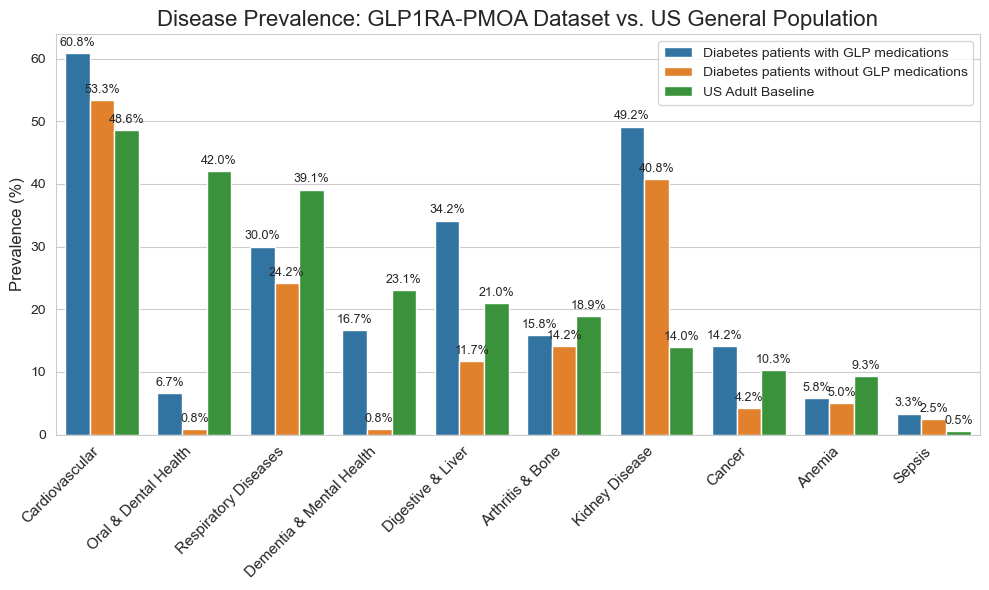

In [145]:
# 6. Aggregate Stats


# total_patients = len(data)
# all_groups_flat = [g for sublist in patient_groups_list for g in sublist]
# group_counts = pd.Series(all_groups_flat).value_counts()
# dataset_prevalence = (group_counts / total_patients) * 100

# 7. Define US Reference Data (Exact match to your provided Markdown table)
us_prevalence_sources = {
    'Cardiovascular': 48.6,       # AHA 2023
    'Oral & Dental Health': 42.0, # CDC Periodontal
    'Respiratory Diseases': 39.1, # Pulmonary Therapy 2022
    'Dementia & Mental Health': 23.1, # NIMH
    'Digestive & Liver': 21.0,    # NIDDK
    'Arthritis & Bone': 18.9,     # CDC Arthritis
    'Kidney Disease': 14.0,       # CDC CKD
    #'Diabetes': 11.3,             # CDC Data Brief 516
    'Cancer': 10.3,               # CDC FastStats
    'Anemia': 9.3,                # CDC Data Brief 519
    'Sepsis': 0.5                 # CDC Sepsis
}

# 8. Create Final DataFrame
comparison_df = pd.DataFrame({
    'Condition': us_prevalence_sources.keys(),
    'US_Pop_Rate': us_prevalence_sources.values()
})

# Map calculated prevalence. 'Sepsis' will be NaN here initially.
comparison_df['Dataset_Rate_case'] = comparison_df['Condition'].map(dataset_prevalence_case).fillna(0)
comparison_df['Dataset_Rate_control'] = comparison_df['Condition'].map(dataset_prevalence_control).fillna(0)

# ---------------------------------------------------------
# MANUAL OVERRIDE FOR SEPSIS
# ---------------------------------------------------------
# comparison_df.loc[comparison_df['Condition']=='Sepsis', 'Dataset_Rate'] = (2139 / len(data)) * 100

# # Sort for plotting
# comparison_df = comparison_df.sort_values('Dataset_Rate', ascending=False)

print("Prevalence Comparison Table:")
display(comparison_df.round(2))

# 9. Plot
plt.figure(figsize=(10, 6))
plot_data = comparison_df.melt(id_vars='Condition', 
                               value_vars=['Dataset_Rate_case', 'Dataset_Rate_control', 'US_Pop_Rate'], 
                               var_name='Source', value_name='Prevalence (%)')

plot_data['Source'] = plot_data['Source'].replace({
    'Dataset_Rate_case': 'Diabetes patients with GLP medications', 
    'Dataset_Rate_control': 'Diabetes patients without GLP medications', 
    'US_Pop_Rate': 'US Adult Baseline'
})

sns.set_style("whitegrid")
# Create barplot
ax = sns.barplot(data=plot_data, x='Condition', y='Prevalence (%)', hue='Source')

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.title('Disease Prevalence: GLP1RA-PMOA Dataset vs. US General Population', fontsize=16)
plt.ylabel('Prevalence (%)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.legend(title=None)
plt.tight_layout()
plt.show()